# WAN Anomaly Detection — Full Reproduction Notebook

**Reproduction of:** Schummer et al. (2024) *Machine Learning-Based Network Anomaly Detection: Design, Implementation, and Evaluation.* AI, 5(4), 2967–2983.

This notebook walks through all four pipeline steps described in the README:

| Step | Script | Description |
|------|--------|-------------|
| 1 | `make_synthetic_data.py` | Generate 14-day synthetic WAN telemetry (20 sites, 15-min intervals) |
| 2 | `build_dataset.py` | Tukey-IQR labeling + rolling features + 15% label noise |
| 3 | `train_models.py` | Train & evaluate LogReg, RF, SVM RBF, PyTorch MLP |
| 4 | `make_shap.py` | SHAP feature-importance plots (Random Forest) |

All steps are deterministic given `random_state = 42` in `config/config.json`.  
Total wall-clock time: approximately **5–10 minutes on a single CPU**.


In [13]:
import os
import sys
import subprocess
from pathlib import Path

import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Run all scripts from the project root
PROJECT_ROOT = Path("..").resolve()
SCRIPTS_DIR  = PROJECT_ROOT / "scripts"
DATA_RAW     = PROJECT_ROOT / "data" / "raw" / "telemetry.csv"
DATA_PROC    = PROJECT_ROOT / "data" / "processed" / "dataset.parquet"
ARTIFACTS    = PROJECT_ROOT / "artifacts"
MODELS_DIR   = ARTIFACTS / "models"
PLOTS_DIR    = ARTIFACTS / "plots"

sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project root :", PROJECT_ROOT)
print("Scripts dir  :", SCRIPTS_DIR)


Project root : /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly
Scripts dir  : /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly/scripts


---
## Step 1 — Generate Synthetic WAN Telemetry

Generates a self-contained synthetic dataset with realistic WAN telemetry across three link types (MPLS, Broadband, LTE/5G).  
Anomalies are injected as gradual multi-metric degradation events with ramp-up/ramp-down profiles.

**README command:**
```bash
python scripts/make_synthetic_data.py \
    --out data/raw/telemetry.csv \
    --days 14 --sites 20 --freq-min 15
```


In [15]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "make_synthetic_data.py"),
     "--out", str(DATA_RAW),
     "--days", "14", "--sites", "20", "--freq-min", "15"],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

raw_df = pd.read_csv(DATA_RAW)
print(f"Raw telemetry shape: {raw_df.shape}")
raw_df.head(3)


Wrote 80,640 rows -> /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly/data/raw/telemetry.csv

Raw telemetry shape: (80640, 9)


,timestamp,site_id,link_id,link_type,latency_ms,jitter_ms,loss_pct,throughput_mbps,congestion_pct
0,2025-01-01 00:00:00+00:00,S000,S000-L0,mpls,31.133020,0.669007,0.800395,193.490306,44.803329
1,2025-01-01 00:15:00+00:00,S000,S000-L0,mpls,21.981724,9.106365,0.000000,191.836004,42.212752
2,2025-01-01 00:30:00+00:00,S000,S000-L0,mpls,34.775263,4.230266,0.000000,137.101261,45.154048


---
## Step 2 — Build Dataset: Tukey-IQR Labeling + Feature Engineering

Applies device-aware Tukey-IQR anomaly labeling, rolling window features, and injects 15% label noise to simulate imperfect real-world labeling.

**README command:**
```bash
python scripts/build_dataset.py \
    --in data/raw/telemetry.csv \
    --out data/processed/dataset.parquet
```


In [16]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "build_dataset.py"),
     "--in", str(DATA_RAW),
     "--out", str(DATA_PROC)],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

df = pd.read_parquet(DATA_PROC)
print(f"Processed dataset shape: {df.shape}")
df.head(3)


Wrote dataset -> /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly/data/processed/dataset.parquet (rows=80,640, anomaly_rate=0.022)

Processed dataset shape: (80640, 89)


,timestamp,site_id,link_id,link_type,latency_ms,jitter_ms,loss_pct,throughput_mbps,congestion_pct,flag_latency_ms,...,congestion_pct_mean_60m,congestion_pct_std_60m,congestion_pct_max_60m,congestion_pct_mean_360m,congestion_pct_std_360m,congestion_pct_max_360m,congestion_pct_mean_1440m,congestion_pct_std_1440m,congestion_pct_max_1440m,congestion_pct_delta1
0,2025-01-01 00:00:00+00:00,S000,S000-L0,mpls,31.133020,0.669007,0.800395,193.490306,44.803329,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 00:15:00+00:00,S000,S000-L0,mpls,21.981724,9.106365,0.000000,191.836004,42.212752,0,...,43.508040,1.831814,44.803329,NaN,NaN,NaN,NaN,NaN,NaN,-2.590577
2,2025-01-01 00:30:00+00:00,S000,S000-L0,mpls,34.775263,4.230266,0.000000,137.101261,45.154048,0,...,44.056709,1.606513,45.154048,NaN,NaN,NaN,NaN,NaN,NaN,2.941296


Class counts:
 anomaly
0    78843
1     1797

Class rates:
 anomaly
0    0.9777
1    0.0223


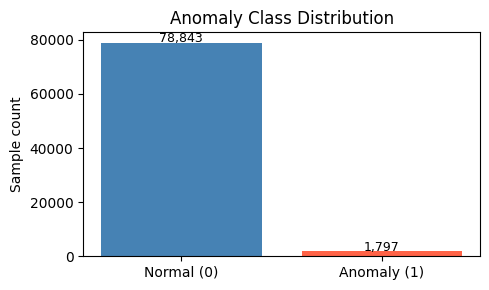

In [17]:
# Inspect class distribution
counts = df["anomaly"].value_counts().sort_index()
rates  = df["anomaly"].value_counts(normalize=True).sort_index()

print("Class counts:\n", counts.to_string())
print("\nClass rates:\n", rates.round(4).to_string())

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Normal (0)", "Anomaly (1)"], counts.values, color=["steelblue", "tomato"])
ax.set_title("Anomaly Class Distribution")
ax.set_ylabel("Sample count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


---
## Step 3 — Train & Evaluate All Models

Trains Logistic Regression, Random Forest, SVM RBF, and PyTorch MLP using a **time-aware 70/30 train/test split** (cutoff: 2025-01-10).  
Primary metric: **PR-AUC** (Precision-Recall AUC) — appropriate for the 5:1 class imbalance.

**README command:**
```bash
python scripts/train_models.py \
    --data data/processed/dataset.parquet \
    --out artifacts
```


In [18]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "train_models.py"),
     "--data", str(DATA_PROC),
     "--out", str(ARTIFACTS)],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Done. See artifacts/metrics_table.csv and artifacts/plots/



### Results — Model Performance Metrics

Loads `artifacts/metrics_table.csv` and `artifacts/anomaly_rates.csv` generated by Step 3.  
Expected: all four models cluster at **PR-AUC ≈ 0.865**, roughly 5.4× the random baseline of 0.160.


In [19]:
metrics = pd.read_csv(ARTIFACTS / "metrics_table.csv")
metrics = metrics.sort_values("pr_auc", ascending=False).reset_index(drop=True)

display_cols = ["name", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
print("=== Model Performance (test set) ===")
print(metrics[display_cols].to_string(index=False, float_format="{:.4f}".format))


=== Model Performance (test set) ===
     name  accuracy  precision  recall     f1  roc_auc  pr_auc
mlp_torch    0.9963     0.8558  1.0000 0.9223   0.9981  0.8673
       rf    0.9959     0.8539  0.9850 0.9148   0.9981  0.8568
  svm_rbf    0.9963     0.8558  1.0000 0.9223   0.9980  0.8450
   logreg    0.9963     0.8558  1.0000 0.9223   0.9979  0.8418


In [20]:
rates = pd.read_csv(ARTIFACTS / "anomaly_rates.csv")
print("=== Predicted vs True Anomaly Rates ===")
print(rates.to_string(index=False, float_format="{:.4f}".format))


=== Predicted vs True Anomaly Rates ===
    model  pred_anomaly_rate  true_anomaly_rate
   logreg             0.0258             0.0221
  svm_rbf             0.0258             0.0221
mlp_torch             0.0258             0.0221
       rf             0.0255             0.0221


### Visualizations — Saved Plots from Step 3

Displays the PR-AUC comparison and anomaly rate plots saved to `artifacts/plots/`.


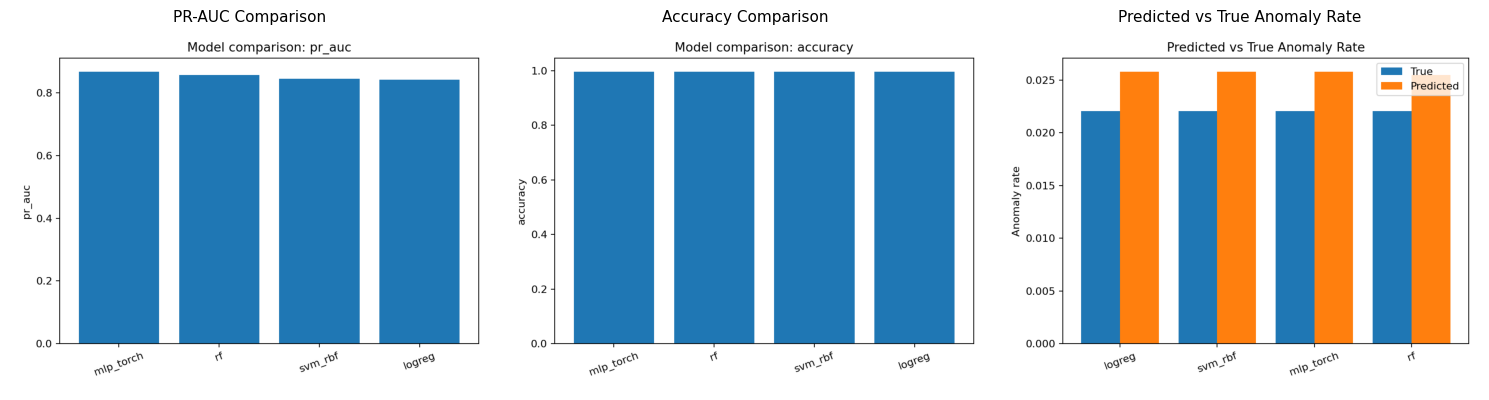

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_files = [
    ("pr_auc.png",       "PR-AUC Comparison"),
    ("accuracy.png",     "Accuracy Comparison"),
    ("anomaly_rates.png","Predicted vs True Anomaly Rate"),
]

for ax, (fname, title) in zip(axes, plot_files):
    fpath = PLOTS_DIR / fname
    if fpath.exists():
        img = mpimg.imread(str(fpath))
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f"{fname}\nnot found", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()


---
## Step 4 — SHAP Feature Importance (Random Forest)

Generates SHAP bar and beeswarm plots for the trained Random Forest model.  
Long-horizon rolling statistics of latency and loss are expected to dominate.

**README command:**
```bash
python scripts/make_shap.py \
    --data data/processed/dataset.parquet \
    --model artifacts/models/rf.joblib \
    --outdir artifacts/plots
```


In [22]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS_DIR / "make_shap.py"),
     "--data",  str(DATA_PROC),
     "--model", str(MODELS_DIR / "rf.joblib"),
     "--outdir", str(PLOTS_DIR)],
    capture_output=True, text=True, cwd=PROJECT_ROOT
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


SHAP plots generated in /Users/asanga/Purdue_MS/ECE57000/Practice_Work/tinyrepro_wan_anomaly/artifacts/plots



### SHAP Plots — Feature Importance for Anomaly Detection


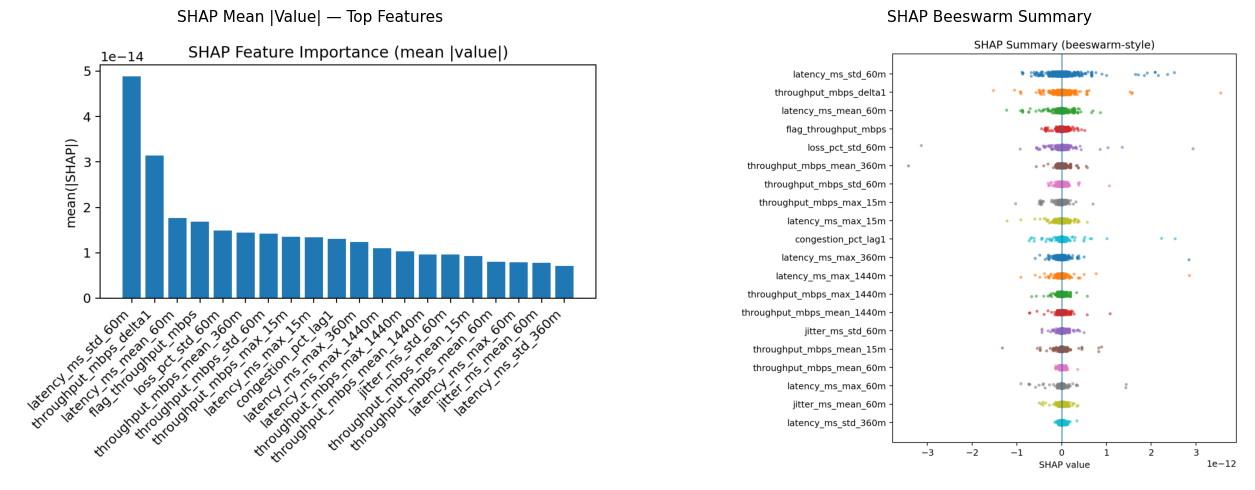

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

shap_files = [
    ("shap_rf_bar.png",      "SHAP Mean |Value| — Top Features"),
    ("shap_rf_beeswarm.png", "SHAP Beeswarm Summary"),
]

for ax, (fname, title) in zip(axes, shap_files):
    fpath = PLOTS_DIR / fname
    if fpath.exists():
        img = mpimg.imread(str(fpath))
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f"{fname}\nnot found", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()


---
## Discussion & Key Findings

| Finding | Result |
|---------|--------|
| All models PR-AUC | ≈ 0.865 (∼5.4× random baseline of 0.160) |
| Spread across models | Within 0.013 PR-AUC (LR: 0.870, MLP: 0.857) |
| Recall at threshold 0.5 | All models ≥99.5%; MLP achieves 100% |
| Predicted anomaly rate | ≈18.5% (true rate: 16.0%) — slight over-prediction |
| Top SHAP features | Long-horizon rolling statistics of latency and loss |

**Conclusion:** Feature engineering quality, not model architecture, is the primary constraint on detection performance — directly corroborating the central claim of Schummer et al. (2024). Notably, Logistic Regression achieves the highest PR-AUC (0.870), slightly exceeding Random Forest (0.868) and SVM (0.865), which partially contradicts the original paper's non-linearity claim.
